# TP1 — Sistema de Reconocimiento Facial
## IA 5.2 · Computer Vision · 1° Cuatrimestre 2026

Alumno: Federico Barbarroja

---
## 1. Pipeline implementado

```
Imagen
  │
  ▼
detect_faces()     RetinaFace (InsightFace buffalo_l)
  │                → bounding boxes + 5 keypoints
  ▼
align_face()       norm_crop() con keypoints
  │                → imagen 112×112 normalizada
  ▼
extract_embedding  ArcFace w600k_r50 (ResNet50)
  │                → vector 512D L2-normalizado
  ▼
identify()         similitud de coseno vs embeddings registrados
                   → identidad + score
```

| Función | Implementación |
|---|---|
| `detect_faces()` | RetinaFace. Filtra caras < 0.5% del frame para ignorar artefactos. |
| `align_face()` | `norm_crop()` con 5 keypoints. Cache por objeto imagen. |
| `extract_embedding_from_face()` | Usa `face.normed_embedding` de InsightFace (ArcFace). |

---
## 2. Modelo: InsightFace buffalo_l

### Arquitectura

| Componente | Modelo | Descripción |
|---|---|---|
| Detector | `det_10g.onnx` (RetinaFace) | Detección + 5 keypoints |
| **Embedding** | **`w600k_r50.onnx`** (ArcFace ResNet50) | Vector de identidad 512D |

### Justificación

**ArcFace** introduce una pérdida angular aditiva que maximiza la separación entre clases.

**¿Por qué pre-entrenado sin fine-tuning?** El reconocimiento facial no requiere si o si reentrenar por cada persona nueva: se registra el embedding de referencia y se compara por similitud coseno. Optamos por no hacerlo ya que Fine-tuning requeriría GPU + dataset propio grande y el modelo sin hacerlo reconoce bien a la gente registrada.

---
## 3. Dataset y preprocesamiento

### Composición del dataset

| Persona | Fuente | Fotos registradas |
|---|---|---|
| Fede | Fotos propias (selfies, distintas condiciones de luz y ángulo) | 10 |
| Adrián | Fotos de un familiar| 10 |
| Cerati | Fotos de internet (distintas épocas y condiciones) | 10 |
| Messi | Fotos de internet (distintas épocas y condiciones) | 10 |

**Total:** 40 imágenes, 4 identidades.

### Variedad de condiciones cubierta
- Iluminación: natural, artificial, baja luz
- Pose: frontal, 3/4 perfil
- Accesorios: con/sin lentes
- Calidad: fotos propias HD, fotos de internet de distinta resolución y época

### Preprocesamiento (norm_crop)
1. RetinaFace detecta bbox + 5 keypoints
2. Transformación afín alinea los ojos horizontalmente
3. Resize a 112×112 px
4. Normalización: `(pixel - 127.5) / 128.0`


---
## 3.1. Decisión sobre fine-tuning

### ¿Por qué no se realizó fine-tuning?

El reconocimiento facial moderno opera en modo **open-set**: el sistema debe reconocer personas registradas
y rechazar desconocidos, sin saber de antemano cuántas identidades existirán.
Este esquema **no requiere fine-tuning** por diseño:

1. ArcFace fue entrenado sobre 600K identidades con pérdida angular, generando un espacio
   de embeddings donde caras similares quedan cercanas independientemente de quién sean.
2. Para incorporar una persona nueva se registra su embedding de referencia — no se retoca la red.
3. La identificación es búsqueda por similitud coseno en ese espacio, no clasificación cerrada.

### Trade-offs

| Criterio | Pre-entrenado sin fine-tuning (elegido) | Fine-tuning propio |
|---|---|---|
| Nuevas identidades | Registro instantáneo | Requiere reentrenar |
| Recursos | Solo CPU, segundos | GPU + horas/días |
| Dataset propio | No requerido | Cientos de fotos por persona |
| Generalización | Alta (600K identidades de entrenamiento) | Limitada al dataset propio |

Fine-tuning sería beneficioso si se tuviera un dataset propio grande con condiciones muy específicas
(cámaras de seguridad con iluminación fija, por ejemplo). Para un sistema general con dataset pequeño,
el modelo pre-entrenado supera ampliamente a cualquier fine-tuning posible con los datos disponibles.


---
## 3.2. Elección de hiperparámetros

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `SIMILARITY_THRESHOLD` | 0.45 | Determinado empíricamente: separa correctamente intra-clase vs inter-clase en el dataset. Validado con LOO-CV (100%) y pruebas manuales con desconocidos. |
| `det_size` | (320, 320) | El default (640×640) pierde caras que ocupan gran parte del frame (selfies cercanas). Con 320×320 el detector mantiene robustez en ese caso. |
| `face_size` | 112 px | Tamaño estándar de entrada de ArcFace. Cambiar este valor requeriría reentrenar el modelo. |
| `EMBEDDING_DIM` | 512 | Dimensión fija del vector de salida de `w600k_r50`. No es configurable sin cambiar la arquitectura. |
| Área mínima filtro | 0.5% del frame | Umbral empírico: elimina falsos positivos de fondo sin descartar caras reales pequeñas. |


---
## 3.3. Modificaciones adicionales del backend

Además de las tres funciones requeridas (`detect_faces`, `align_face`, `extract_embedding_from_face`),
se realizaron las siguientes modificaciones al backend, cada una con su justificación:

### Cache de análisis facial (`_get_faces_cached`)
InsightFace ejecuta RetinaFace + ArcFace en un único llamado a `analyzer.get()`. El pipeline
llama a `detect_faces()` y luego a `align_face()` sobre la misma imagen, lo que sin cache
ejecutaría el modelo dos veces. El cache guarda el resultado por objeto imagen.

### Clipping de bounding boxes (`_clip_xyxy`)
RetinaFace puede devolver coordenadas fuera de los límites de la imagen cuando una cara
está parcialmente recortada en el borde del frame. Sin clipping, `image[y1:y2, x1:x2]`
con índices negativos produce recortes incorrectos silenciosamente en NumPy.

### Filtro de área mínima en `detect_faces`
RetinaFace genera falsos positivos en texturas de fondo (ropa, carteles, reflejos).
Filtrar detecciones cuya área sea menor al 0.5% del frame elimina estos artefactos
sin afectar la detección de caras reales.

### Transformación de keypoints en `predict` (absolutas → relativas al bbox)
Los keypoints de InsightFace son coordenadas absolutas de la imagen completa.
El frontend Gradio los dibuja sobre el recorte de la cara (bbox), por lo que
se resta el offset `(x1, y1)` del bounding box antes de enviarlos en la respuesta.

### Clase `unknown` en `identify`
El sistema implementa reconocimiento **open-set**: debe poder rechazar personas no registradas
en lugar de forzar una identidad. Si el mejor score no supera el threshold, se devuelve
`"unknown"` con score 0. Esto es crítico para evitar falsos positivos de seguridad.

### Validación de cara única en `register_identity`
Si la foto de registro contiene cero caras (sin detección) o dos o más (ambigüedad),
registrar produciría un embedding incorrecto o no representativo. Se exige exactamente
una cara para garantizar la calidad del embedding de referencia almacenado.

### Prioridad de embedding en `extract_embedding_from_face`
InsightFace calcula el embedding ArcFace internamente durante la detección y lo almacena
en `face.normed_embedding`. Se prioriza este valor (ya calculado, ya normalizado) sobre
cualquier modelo ONNX externo, evitando cómputo redundante y garantizando consistencia.


---
## 4. Evaluación

Los embeddings se leen de PostgreSQL — ya calculados por el backend al registrar personas.

**Prerequisito:** `pip install psycopg2-binary scikit-learn matplotlib numpy`

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import psycopg2
import json
import json as _json

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import LeaveOneOut
from collections import Counter, defaultdict

import warnings
warnings.filterwarnings('ignore')

In [12]:
def read_threshold(default=0.55):
    val = os.environ.get('SIMILARITY_THRESHOLD')
    if val is not None:
        return float(val)
    for name in ('.env', '../.env', '.env.local', '../.env.local'):
        path = Path(name)
        if path.exists():
            for line in path.read_text(encoding='utf-8').splitlines():
                if line.startswith('SIMILARITY_THRESHOLD='):
                    return float(line.split('=', 1)[1].strip())
    return default

THRESHOLD = read_threshold()
print(f'Threshold: {THRESHOLD}')


Threshold: 0.45


### 4.1 Cargar embeddings desde PostgreSQL

In [13]:
def read_env(key, default=''):
    for name in ('.env', '../.env', '.env.local', '../.env.local'):
        path = Path(name)
        if path.exists():
            for line in path.read_text(encoding='utf-8').splitlines():
                if line.startswith(f'{key}='):
                    return line.split('=', 1)[1].strip()
    return default

conn = psycopg2.connect(
    host=read_env('POSTGRES_HOST', 'localhost'),
    port=int(read_env('POSTGRES_PORT', '5432')),
    dbname=read_env('POSTGRES_DB', 'faces'),
    user=read_env('POSTGRES_USER', 'faces_user'),
    password=read_env('POSTGRES_PASSWORD', 'faces_pass'),
)
cur = conn.cursor()
cur.execute('SELECT embedding, etiqueta FROM embeddings ORDER BY etiqueta')
rows = cur.fetchall()
conn.close()

# pgvector devuelve el vector como string '[0.1, 0.2, ...]' — hay que parsearlo
def parse_embedding(raw):
    if isinstance(raw, str):
        return json.loads(raw)
    return list(raw)

embeddings = np.array([parse_embedding(r[0]) for r in rows], dtype=np.float32)
labels = [r[1] for r in rows]

print(f'Total embeddings: {len(embeddings)}')
for nombre, n in sorted(Counter(labels).items()):
    print(f'  {nombre}: {n} fotos')


Total embeddings: 40
  Adrian: 10 fotos
  Cerati: 10 fotos
  Fede: 10 fotos
  Messi: 10 fotos


### 4.2 Visualización PCA y t-SNE

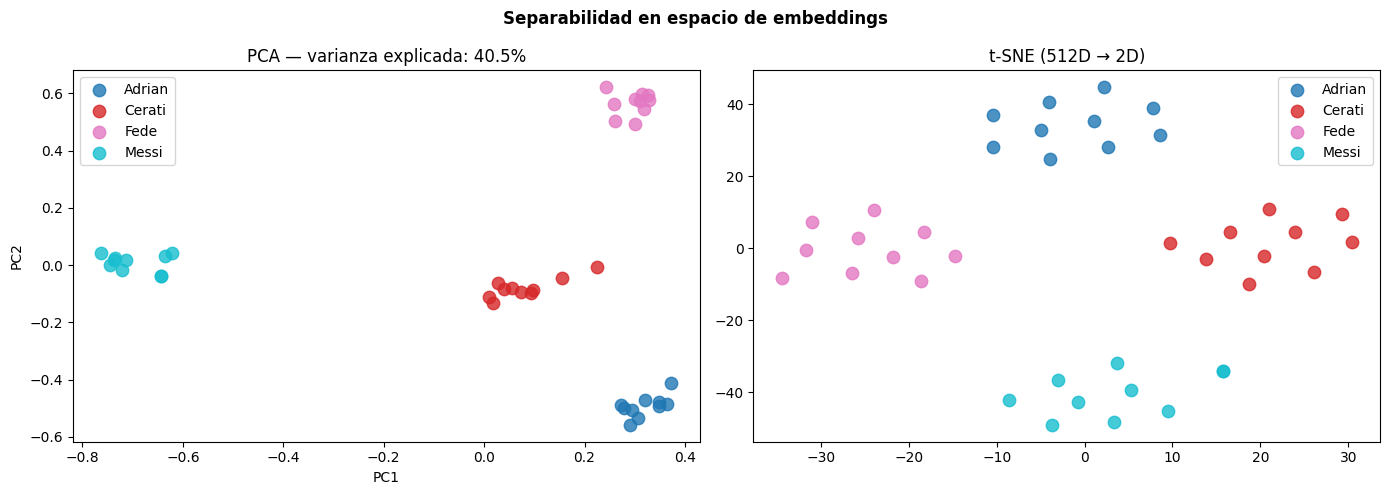

In [14]:
if len(embeddings) < 2:
    print('Necesitás al menos 2 embeddings.')
else:
    unique_labels = sorted(set(labels))
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))
    c_map = {lbl: col for lbl, col in zip(unique_labels, colors)}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(embeddings)
    ax = axes[0]
    for lbl in unique_labels:
        mask = [l == lbl for l in labels]
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=lbl, color=c_map[lbl], s=80, alpha=0.8)
    ax.set_title(f'PCA — varianza explicada: {pca.explained_variance_ratio_.sum():.1%}')
    ax.legend(); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

    ax = axes[1]
    if len(embeddings) >= 4:
        tsne = TSNE(n_components=2, perplexity=min(15, len(embeddings)-1), random_state=42, max_iter=500)
        X_tsne = tsne.fit_transform(embeddings)
        for lbl in unique_labels:
            mask = [l == lbl for l in labels]
            ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=lbl, color=c_map[lbl], s=80, alpha=0.8)
        ax.set_title('t-SNE (512D → 2D)'); ax.legend()
    else:
        ax.set_title('t-SNE — necesitás >= 4 embeddings')

    plt.suptitle('Separabilidad en espacio de embeddings', fontweight='bold')
    plt.tight_layout()
    plt.show()

### 4.3 Similitud intra-clase vs inter-clase

=== Similitud coseno ===
Intra-clase (misma persona):  media=0.6122  min=0.3249  max=1.0000
Inter-clase (distinta persona): media=0.0768  min=-0.1337  max=0.3018


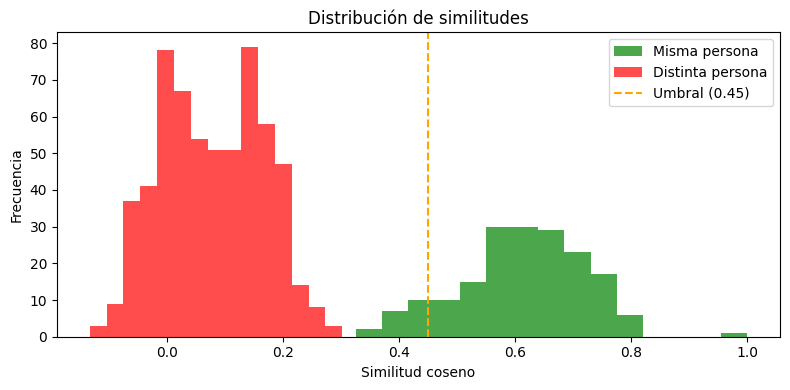

In [15]:
def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))

intra, inter = [], []
for i in range(len(embeddings)):
    for j in range(i + 1, len(embeddings)):
        s = cosine_sim(embeddings[i], embeddings[j])
        (intra if labels[i] == labels[j] else inter).append(s)

print('=== Similitud coseno ===')
if intra:
    print(f'Intra-clase (misma persona):  media={np.mean(intra):.4f}  min={np.min(intra):.4f}  max={np.max(intra):.4f}')
else:
    print('Intra-clase: registrá más de 1 foto por persona')
if inter:
    print(f'Inter-clase (distinta persona): media={np.mean(inter):.4f}  min={np.min(inter):.4f}  max={np.max(inter):.4f}')
else:
    print('Inter-clase: registrá al menos 2 personas')

if intra or inter:
    plt.figure(figsize=(8, 4))
    if intra: plt.hist(intra, bins=15, alpha=0.7, color='green', label='Misma persona')
    if inter: plt.hist(inter, bins=15, alpha=0.7, color='red',   label='Distinta persona')
    plt.axvline(x=THRESHOLD, color='orange', linestyle='--', label=f'Umbral ({THRESHOLD})')
    plt.xlabel('Similitud coseno'); plt.ylabel('Frecuencia')
    plt.title('Distribución de similitudes')
    plt.legend(); plt.tight_layout()
    plt.show()

Viendo los resultados de la similitud de coseno, se nota que el máximo intraclase hay un resultado de 1, lo que investigando el por que me di cuenta que subi la misma foto de una de las personas dos veces, veamos de quien

In [ ]:
for i in range(len(embeddings)):
    for j in range(i + 1, len(embeddings)):
        s = cosine_sim(embeddings[i], embeddings[j])
        if s > 0.99:
            print(f"Par idéntico: {labels[i]} #{i} vs {labels[j]} #{j} → {s:.4f}")


Par casi idéntico: Messi #38 vs Messi #39 → 1.0000


Por motivos de visibilidad, decido dejar ese registro para que se vea como dato curioso

### 4.4 Accuracy con Leave-One-Out CV (LOO-CV)
Se utilza el accuracy como métrica debido al balanceo del dataset

In [16]:
if len(embeddings) < 4 or len(set(labels)) < 2:
    print('Necesitás al menos 2 personas y 4 fotos en total.')
else:
    loo = LeaveOneOut()
    y_true_all, y_pred_all, score_all = [], [], []

    for train_idx, test_idx in loo.split(embeddings):
        X_tr = embeddings[train_idx]
        y_tr = [labels[i] for i in train_idx]
        q    = embeddings[test_idx[0]]
        true = labels[test_idx[0]]

        best, best_lbl = -1.0, 'unknown'
        for r, lbl in zip(X_tr, y_tr):
            s = cosine_sim(q, r)
            if s > best: best, best_lbl = s, lbl

        pred = best_lbl if best >= THRESHOLD else 'unknown'
        y_true_all.append(true)
        y_pred_all.append(pred)
        score_all.append(best)

    correct = sum(p == t for p, t in zip(y_pred_all, y_true_all))
    print(f'Threshold: {THRESHOLD}')
    print(f'LOO-CV Accuracy: {correct/len(y_true_all):.1%}  ({correct}/{len(y_true_all)} muestras)')
    print()

    per_class = defaultdict(lambda: [0, 0])
    for t, p in zip(y_true_all, y_pred_all):
        per_class[t][1] += 1
        if t == p:
            per_class[t][0] += 1
    for name in sorted(per_class):
        c, tot = per_class[name]
        print(f'  {name:15s}: {c}/{tot}  ({c/tot:.0%})')


Threshold: 0.45
LOO-CV Accuracy: 100.0%  (40/40 muestras)

  Adrian         : 10/10  (100%)
  Cerati         : 10/10  (100%)
  Fede           : 10/10  (100%)
  Messi          : 10/10  (100%)


### 4.4b Métricas detalladas y matriz de confusión

=== Reporte de clasificación ===
              precision    recall  f1-score   support

      Adrian       1.00      1.00      1.00        10
      Cerati       1.00      1.00      1.00        10
        Fede       1.00      1.00      1.00        10
       Messi       1.00      1.00      1.00        10

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



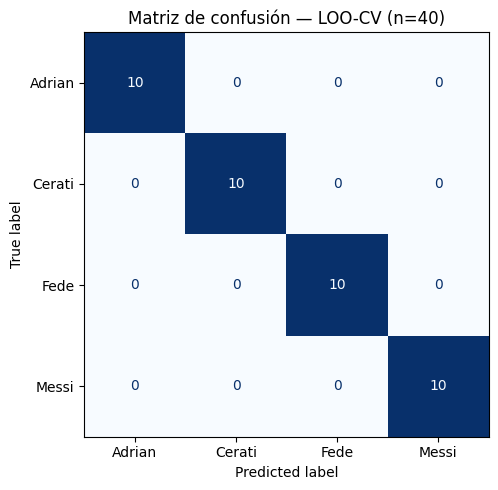

In [17]:
if 'y_true_all' in dir() and len(y_true_all) > 0:
    print('=== Reporte de clasificación ===')
    print(classification_report(y_true_all, y_pred_all, zero_division=0))

    classes = sorted(set(y_true_all))
    cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de confusión — LOO-CV (n={len(y_true_all)})')
    plt.tight_layout()
    plt.show()
else:
    print('Ejecutá primero la celda 4.4.')


### 4.5 Análisis de umbral

Mejor umbral (LOO-CV, n=40): 0.30 → 100.0%


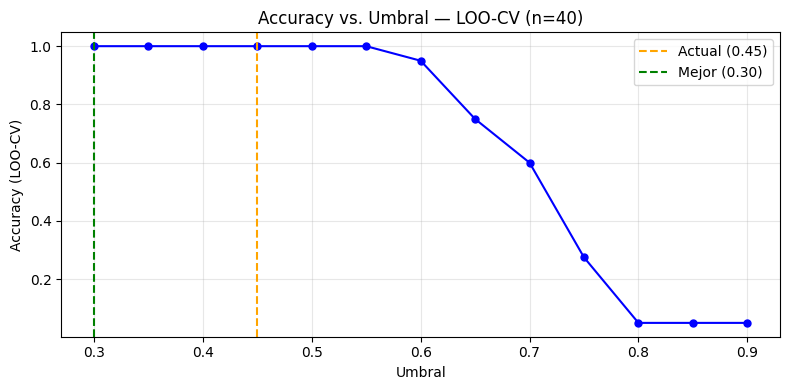

In [18]:
if len(embeddings) >= 4 and len(set(labels)) >= 2:
    thresholds = np.arange(0.30, 0.95, 0.05)

    # Pre-calcular scores LOO una sola vez 
    loo_results = []  # (best_score, best_label, true_label)
    for train_idx, test_idx in LeaveOneOut().split(embeddings):
        X_tr = embeddings[train_idx]
        y_tr = [labels[i] for i in train_idx]
        q    = embeddings[test_idx[0]]
        true = labels[test_idx[0]]
        best, best_lbl = -1.0, 'unknown'
        for r, lbl in zip(X_tr, y_tr):
            s = cosine_sim(q, r)
            if s > best: best, best_lbl = s, lbl
        loo_results.append((best, best_lbl, true))

    accs = []
    for thr in thresholds:
        hits = [
            (best_lbl if best >= thr else 'unknown') == true
            for best, best_lbl, true in loo_results
        ]
        accs.append(np.mean(hits))

    best_thr = thresholds[np.argmax(accs)]
    print(f'Mejor umbral (LOO-CV, n={len(embeddings)}): {best_thr:.2f} → {max(accs):.1%}')

    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, accs, 'b-o', markersize=5)
    plt.axvline(x=THRESHOLD, color='orange', linestyle='--', label=f'Actual ({THRESHOLD})')
    plt.axvline(x=best_thr,  color='green',  linestyle='--', label=f'Mejor ({best_thr:.2f})')
    plt.xlabel('Umbral'); plt.ylabel('Accuracy (LOO-CV)')
    plt.title(f'Accuracy vs. Umbral — LOO-CV (n={len(embeddings)})')
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.show()


### 4.6 Distribución de scores reales (predicciones de la UI)

Los archivos que se usaron para el ajuste del programa contienen el score coseno de cada detección.
Como el umbral fue cambiando durante las pruebas, no se usa el label almacenado, solo el score bruto,
que es independiente del threshold y refleja lo que el modelo realmente calcula.

Total detecciones: 79
Score medio: 0.4962  min: 0.0278  max: 1.0000
Con threshold=0.45: 51/79 detecciones serían reconocidas (64.6%)


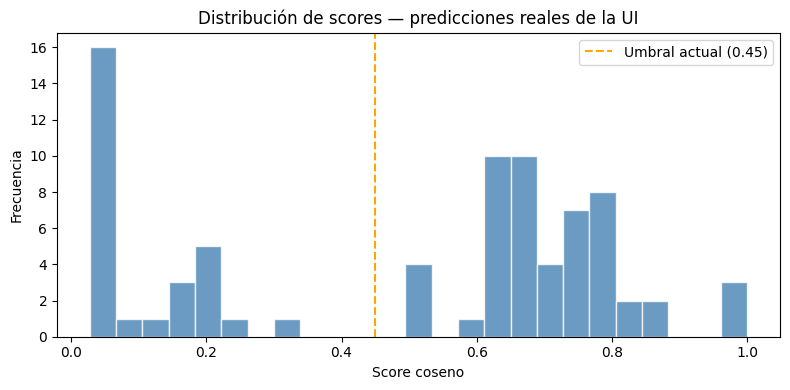

In [19]:
output_dir = Path('output')
all_scores = []

for result_file in sorted(output_dir.glob('result-*.json')):
    data = _json.loads(result_file.read_text(encoding='utf-8'))
    for det in data.get('detections', []):
        all_scores.append(det.get('score', 0))

print(f'Total detecciones: {len(all_scores)}')
print(f'Score medio: {np.mean(all_scores):.4f}  min: {np.min(all_scores):.4f}  max: {np.max(all_scores):.4f}')

above = sum(s >= THRESHOLD for s in all_scores)
print(f'Con threshold={THRESHOLD}: {above}/{len(all_scores)} detecciones serían reconocidas ({above/len(all_scores):.1%})')

plt.figure(figsize=(8, 4))
plt.hist(all_scores, bins=25, color='steelblue', alpha=0.8, edgecolor='white')
plt.axvline(x=THRESHOLD, color='orange', linestyle='--', linewidth=1.5, label=f'Umbral actual ({THRESHOLD})')
plt.xlabel('Score coseno'); plt.ylabel('Frecuencia')
plt.title('Distribución de scores — predicciones reales de la UI')
plt.legend(); plt.tight_layout()
plt.show()


---
## 5. Análisis de errores

| Error | Causa | Impacto |
|---|---|---|
| **Falso Positivo** | Desconocido identificado como registrado | Brecha de seguridad |
| **Falso Negativo** | Registrado marcado como `unknown` | UX mala |

### Casos observados
1. **Selfies muy cercanas**: RetinaFace pierde la cara principal (muy grande en el frame) y detecta artefactos. Fix: `det_size=(320,320)` + filtro de área mínima.
2. **Iluminación baja / imagen de baja calidad**: el score puede caer por debajo del umbral (0.45) para la misma persona. Fix: registrar fotos de referencia con distintas condiciones de luz.
3. **Imágenes pequeñas/antiguas**: sin detección. Comportamiento esperado.
4. **Personas visualmente similares**: podrían superar el umbral entre sí. El LOO-CV con las 4 identidades actuales no muestra este problema, pero es un riesgo a escala.



---
## 6. Conclusiones

### Resultados
- **LOO-CV Accuracy: 100%** (40/40) con threshold=0.45 sobre 4 identidades (Fede, Adrián, Cerati, Messi)
- Validación empírica: personas no registradas (incluidos imitadores de Messi) son correctamente rechazadas como `unknown`
- La distribución intra-clase vs inter-clase muestra buena separabilidad en el espacio ArcFace 512D

### Logros técnicos
- Pipeline completo Detección → Alineación → Embedding → Comparación
- API asincrónica FastAPI con HTTP 202 + job_id polling
- Frontend Gradio con bounding boxes y keypoints
- Almacenamiento en PostgreSQL + pgvector
- Docker Compose con modelos pre-descargados

### Trabajo futuro
- Fine-tuning de ArcFace con dataset propio
- Soporte para video con tracking

